# 9.1: Working with Sequences

In [23]:
import torch
from torch import nn
from d2l import torch as d2l

## 9.1.3: Training

In [24]:
class Data(d2l.DataModule):
    def __init__(self, batch_size=16, T=1000, num_train=600, tau=4):
        self.save_hyperparameters()
        self.time = torch.arange(1,T+1, dtype=torch.float32)
        self.x = torch.sin(0.01 * self.time) + torch.randn(T) * 0.2 # sine function + additive noise

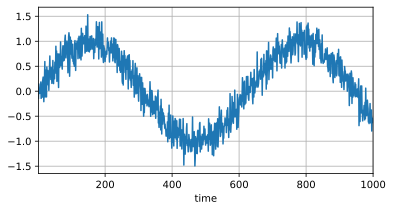

In [25]:
data = Data()
d2l.plot(data.time, data.x, 'time', xlim=[1,1000], figsize=(6,3))

In [26]:
@d2l.add_to_class(Data)
def get_dataloader(self, train):
    features = [self.x[i: self.T-self.tau + i] for i in range(self.tau)]
    self.features = torch.stack(features, 1)
    self.labels = self.x[self.tau:].reshape((-1,1))
    i = slice(0, self.num_train) if train else slice(self.num_train, None)
    return self.get_tensorloader([self.features, self.labels], train, i)

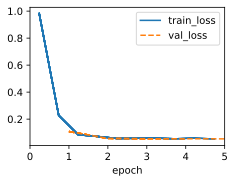

In [27]:
model = d2l.LinearRegression(lr=0.01)
trainer = d2l.Trainer(max_epochs=5)
trainer.fit(model, data)

## 9.1.4: Prediction

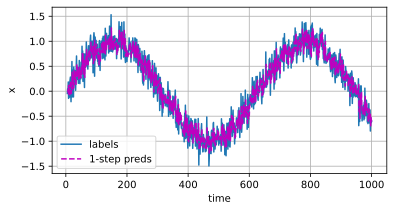

In [28]:
onestep_preds = model(data.features).detach().numpy()
d2l.plot(data.time[data.tau:], [data.labels, onestep_preds], 'time', 'x', legend=['labels', '1-step preds'], figsize=(6,3))

In [29]:
# Use earlier predictions as inputs to our model for making subsequent predictions, projecting forward, one step at a time.
multistep_preds = torch.zeros(data.T)
multistep_preds[:] = data.x
for i in range(data.num_train + data.tau, data.T):
    multistep_preds[i] = model(
        multistep_preds[i - data.tau:i].reshape((1,-1))) # k'th order markov model prediction
multistep_preds = multistep_preds.detach().numpy()

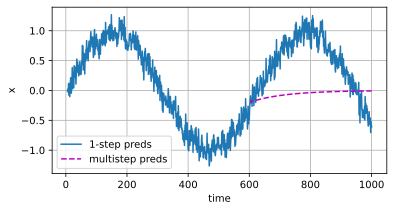

In [30]:
d2l.plot([data.time[data.tau:], data.time[data.num_train + data.tau:]], [onestep_preds, multistep_preds[data.num_train+data.tau:]], 'time', 
         'x', legend=['1-step preds', 'multistep preds'], figsize=(6,3))

In [31]:
def k_step_pred(k):
    features = []
    for i in range(data.tau): # Create overlapping arrays of historical data
        features.append(data.x[i:i+data.T-data.tau-k+1])
    # The (i+tau)-th element stores the (i+1)-step-ahead predictions
    for i in range(k): # Predict the next k entries using k-step-ahead prediction
        preds = model(torch.stack(features[i:i+data.tau],1)) # Append historical sequences together into a data matrix, run batched prediction across all samples 
            # Note: stacking along dim 1 means we stack along columns, not rows.
            # This means we have smth like: 
            # features[1] = [x₁, x₂, x₃, x₄, x₅, x₆]  (historical)
            # features[2] = [x₂, x₃, x₄, x₅, x₆, x₇]  (historical)
            # features[3] = [p₃, p₄, p₅, p₆, p₇, p₈]  (1-step predictions)
            # and append features[4] to it using our newest batch of predictions. features[4] will be the 2-step-ahead predictions.
            # This is also how preds[k-1] models k-step-ahead predictions
            
        features.append(preds.reshape(-1))
    return features[data.tau:]

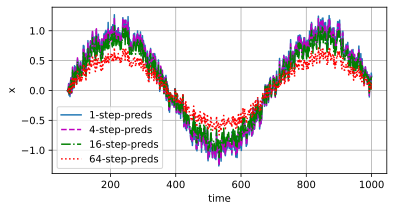

In [32]:
steps = (1,4,16,64)
preds = k_step_pred(steps[-1])
d2l.plot(data.time[data.tau+steps[-1]-1:],
         [preds[k-1].detach().numpy() for k in steps], 'time', 'x',
         legend=[f'{k}-step-preds' for k in steps], figsize=(6,3))

# Summary:

* Two popular choices for sequence data:
    * Autoregressive models
    * Latent variable autoregressive models